## GigaTIME: Virtual Phenotyping from H&E for Tumor Microenvironment Analysis

Routine **Hematoxylin and Eosin (H&E)** imaging is central to diagnostic and translational oncology because it is widely available and preserves tissue architecture, but it does not directly measure molecular markers.

In contrast, **multiplex immunofluorescence (mIF)** resolves protein expression in space and helps characterize the **tumor microenvironment**, including immune infiltration, stromal structure, vascular context, proliferation, and cell death. These are precisely the types of features that matter in oncology discovery and immunotherapy studies.

**GigaTIME** uses computational pathology to infer virtual marker channels from H&E, providing a scalable way to approximate mIF-like spatial protein readouts from routine histology. In this sense, it complements experimental spatial assays: **spatial transcriptomics** motivates the need for spatially resolved molecular context, while GigaTIME offers a pathology-native route to study spatial organization directly from H&E.

Conceptually, GigaTIME works as follows:

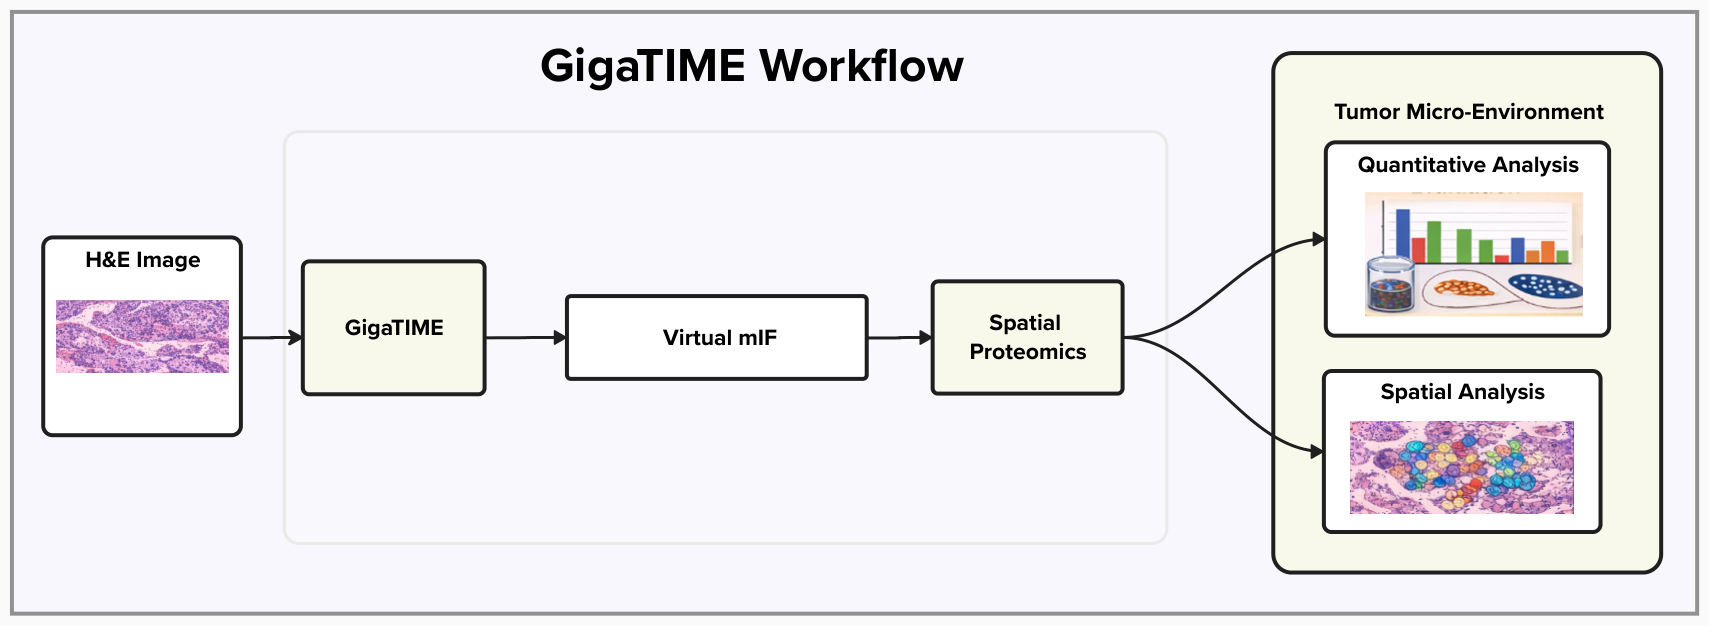
The example paired H&E and mIF fields of view used throughout this notebook have a spatial resolution of approximately 0.23 µm per pixel, which corresponds roughly to **40× magnification** in digital pathology. This high resolution preserves cellular detail, allowing individual nuclei to be resolved and enabling accurate single-cell localization of predicted markers.

For background on the model and broader pathology foundation model context, see the Cell paper: https://www.cell.com/cell/fulltext/S0092-8674(25)01312-1

For more details on Gigatime and the clinical context, review our companion blog: https://aka.ms/gigatime-blog

### What this notebook teaches

- Load paired H&E and reference mIF evaluation data  
- Run endpoint inference or reload saved predictions  
- Convert spatial marker predictions into cell-level phenotypes  
- Place localized predictions back onto H&E to interpret tumor microenvironment context  
- Summarize marker counts for translational interpretation

### Key idea

The core biological step is to move from continuous spatial marker predictions to **cell-level phenotypes**, compare those phenotypes against reference labels, and then project the resulting spatial patterns back onto H&E for interpretable tumor microenvironment analysis.

## Step 1: Data

A set of **50 paired H&E and mIF fields of view** is provided for evaluation. All samples come from a single subject and represent regions of **lung tissue** extracted from whole slide images. The subject is annotated with pathologic staging **T1N0M0 (Stage I)**, indicating an early-stage tumor without lymph node involvement or distant metastasis. Specifically, T1 denotes a small primary lung tumor (≤3 cm), N0 indicates no regional lymph node involvement, and M0 indicates no distant metastasis.

These paired H&E and mIF patches allow us to compare **GigaTIME predictions** against reference molecular measurements. The markers predicted by GigaTIME provide insight into the tumor microenvironment by revealing which cell types are present and how they are spatially organized. For example:

- **CK** highlights tumor (epithelial) regions  
- **CD3, CD4, CD8** identify T-cell populations and their interaction with tumor regions  
- **CD20** marks B cells  
- **CD68, CD11c** highlight macrophages and dendritic cells  
- **Ki67** indicates proliferating cells  
- **PD-1, PD-L1** reflect immune activation or suppression  
- **CD34, Transgelin, Actin** provide structural context such as vasculature and stroma  

By combining these markers, we move from simply visualizing tissue to understanding its biological state—what cells are present, what they are doing, and how they interact.

---

### Download and Setup

Download the dataset:

[Download sample_test_data.zip](https://www.dropbox.com/scl/fi/8ampg43fs2yowt9y6vvr1/sample_test_data.zip?rlkey=bkg4w183qnvkh2dudqy3d8lsg&e=1&st=j2l463ug&dl=0)

After downloading, unzip the archive into your data directory:

```bash
unzip sample_test_data.zip -d ./data/

### Setup and imports

This cell loads the helper module, sets the notebook configuration, and defines the fixed sample-data path used by the rest of the tutorial.

To run the inference you will need to provision the GigaTIME model in your Azure subscription from Azure Foundry model catalog: https://ai.azure.com/catalog/models/GigaTIME/

Once that is done, add the endpoint to your .env file and authenticate to Azure ML, as described in the README.md

### Data discovery and validation

This section loads sample metadata and checks that the paired H&E patches and any saved prediction arrays are available locally.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from healthcareai_toolkit import settings
from healthcareai_toolkit.clients import GigaTimeClient

from virtual_phenotyping_helper import (
    CHANNEL_NAMES,
    DEFAULT_VISUALIZATION_MARKERS,
    EXCLUDED_CHANNELS,
    describe_markers,
    get_marker_count_comparison,
    get_tissue_bbox,
    get_total_marker_count_comparison,
    load_indexed_image_files,
    load_metadata,
    load_sample_records,
    load_saved_predictions,
    plot_overlay_comparison,
    plot_virtual_mif_for_markers,
    render_context_theme,
)

RUN_ENDPOINT_SUBMISSION = True
SAVE_PREDICTIONS = True
SAMPLE_INDEX = 1
SELECTED_MARKERS = DEFAULT_VISUALIZATION_MARKERS

sample_root = Path("SET_YOUR_SAMPLE_ROOT_DIRECTORY_HERE")

data_root = sample_root / "data"
VIRTUAL_PHENOTYPING_MARKERS = [
    marker for marker in CHANNEL_NAMES if marker not in EXCLUDED_CHANNELS
]
VIRTUAL_PHENOTYPING_MARKER_DESCRIPTIONS = {
    "DAPI": "Nuclear marker",
    "PD-1": "T cells and B cells",
    "CD14": "Monocytes",
    "CD4": "T helper cells",
    "T-bet": "NK cells and T cells of CD4+ or CD8+ lineages",
    "CD34": "Vascular marker; also hematopoietic precursors and capillary endothelium",
    "CD68": "Macrophages",
    "CD16": "NK cells; also neutrophils and macrophages depending on isoform",
    "CD11c": "Dendritic cells",
    "CD138": "Plasma cells",
    "CD20": "B cells",
    "CD3": "All T cells",
    "CD8": "Cytotoxic T cells",
    "PD-L1": "Antigen-presenting cells, tumor cells, and vascular endothelium",
    "CK": "Epithelial cell lineage",
    "Ki67": "Proliferating cells, including normal and tumor cells",
    "Tryptase": "Mast cells",
    "Actin-D": "Myofibroblasts",
    "Caspase3-D": "Cells undergoing apoptosis",
    "PHH3-B": "Mitotic spindle marker",
    "Transgelin": "Fibroblasts and smooth muscle",
}

In [3]:
if not sample_root.exists():
    raise FileNotFoundError(f"sample_test_data was not found: {sample_root}")

sample_metadata = load_metadata(sample_root)
sample_metadata["dir_name"] = [data_root] * len(sample_metadata)
indexed_image_files = load_indexed_image_files(sample_metadata)

image_paths = [Path(image_path) for _, image_path in indexed_image_files]
prediction_paths = [
    Path(row["dir_name"]) / f"{row['pair_name']}_pred.npy"
    for _, row in sample_metadata.iterrows()
]

print(f"Using sample root: {sample_root}")
print(f"Total samples in metadata: {len(sample_metadata)}")
print(
    f"H&E images found: {sum(path.exists() for path in image_paths)}/{len(image_paths)}"
)
print(
    f"Saved predictions found: {sum(path.exists() for path in prediction_paths)}/{len(prediction_paths)}"
)
print(f"Requested example sample index: {SAMPLE_INDEX}")

Using sample root: /home/azureuser/cloudfiles/code/Users/data/gigapath/sample_test_data
Total samples in metadata: 50
H&E images found: 50/50
Saved predictions found: 50/50
Requested example sample index: 1


## Step 2: Run inference from endpoint

Before submitting the H&E patches, review the virtual phenotyping output channels. For this tutorial, GigaTIME produces 21 marker outputs that span immune, epithelial, stromal, vascular, proliferative, and apoptotic biology relevant to tumor microenvironment analysis.

The next cell summarizes those markers, and the inference cell after that either submits the images to the endpoint or reloads saved prediction arrays.

In [4]:
print(
    f"GigaTIME virtual phenotyping outputs: {len(VIRTUAL_PHENOTYPING_MARKERS)} markers"
)

marker_table = pd.DataFrame(
    {
        "Marker Name": VIRTUAL_PHENOTYPING_MARKERS,
        "Marker Description": [
            VIRTUAL_PHENOTYPING_MARKER_DESCRIPTIONS[marker]
            for marker in VIRTUAL_PHENOTYPING_MARKERS
        ],
    }
)

display(marker_table)

GigaTIME virtual phenotyping outputs: 21 markers


,Marker Name,Marker Description
0,DAPI,Nuclear marker
1,PD-1,T cells and B cells
2,CD14,Monocytes
3,CD4,T helper cells
4,T-bet,NK cells and T cells of CD4+ or CD8+ lineages
5,CD34,Vascular marker; also hematopoietic precursors...
6,CD68,Macrophages
7,CD16,NK cells; also neutrophils and macrophages dep...
8,CD11c,Dendritic cells
9,CD138,Plasma cells


These predictions are spatial marker-likelihood maps.

At this stage, the outputs are still channel-level probability maps rather than discrete cell calls. The next steps organize them into sample records and then convert them into cell-aware phenotypes for downstream tumor microenvironment analysis.

In [5]:
indexed_image_files = [
    (idx, str(Path(row["dir_name"]) / f"{row['pair_name']}_he.png"))
    for idx, row in sample_metadata.iterrows()
]

if RUN_ENDPOINT_SUBMISSION:

    endpoint = settings.GIGATIME_MODEL_ENDPOINT
    gigatime_client = GigaTimeClient(endpoint)
    submitter = gigatime_client.create_submitter()

    _, prediction_results = submitter.submit(
        image_list=[image_path for _, image_path in indexed_image_files],
        total=len(indexed_image_files),
    )

    prediction_by_index = {
        idx: pred for (idx, _), pred in zip(indexed_image_files, prediction_results)
    }

    if SAVE_PREDICTIONS:
        for idx, row in sample_metadata.iterrows():
            output_path = Path(row["dir_name"]) / f"{row['pair_name']}_pred.npy"
            np.save(output_path, prediction_by_index[idx])

    print(f"Generated predictions: {len(prediction_by_index)}")
else:
    print(
        "Skipping endpoint submission. Set RUN_ENDPOINT_SUBMISSION = True to generate predictions."
    )
    prediction_by_index = load_saved_predictions(sample_metadata)
    print(
        f"Loaded saved predictions: {len(prediction_by_index)}/{len(sample_metadata)}"
    )

100%|██████████| 50/50 [02:15<00:00,  2.71s/it]


Generated predictions: 50


### Build unified sample records

This step combines each H&E patch, its virtual marker predictions, and the provided reference masks into a single sample-level record.

During this record-construction step, the helper also applies the shared nuclei and expanded-cell masks to build **cell-aware localized masks** for both prediction and reference data. In other words, this is where channel-level probability maps are converted into the phenotype-ready representation used later for comparison and tissue-context interpretation.

Those unified records then support three downstream views:

- raw virtual-marker visualization  
- predicted-versus-reference cell-state comparison  
- H&E-based tumor microenvironment interpretation

In [6]:
sample_records = load_sample_records(
    metadata_df=sample_metadata,
    prediction_map=prediction_by_index,
)

available_prediction_indices = [
    idx
    for idx, row in sample_metadata.iterrows()
    if sample_records[row["pair_name"]]["prediction_probability_mask"] is not None
]

if not available_prediction_indices:
    raise ValueError(
        "No predictions are available. Enable endpoint submission or place saved *_pred.npy files in the sample data directory."
    )

sample = (
    SAMPLE_INDEX
    if SAMPLE_INDEX in available_prediction_indices
    else available_prediction_indices[0]
)
selected_pair_name = sample_metadata.iloc[sample]["pair_name"]

print(f"Unified sample records: {len(sample_records)}")
print(f"Samples with predictions: {len(available_prediction_indices)}")
print(f"Selected sample: {selected_pair_name}")

Unified sample records: 50
Samples with predictions: 50
Selected sample: 11120_23908_556_556


## Step 3: Visualize virtual marker predictions before phenotype comparison

This section inspects the raw virtual mIF outputs for a representative sample. The figures below still show the continuous prediction channels themselves, even though the notebook has already assembled cell-aware localized phenotypes in the unified sample records.

That distinction matters: the images in this step answer **what spatial signal did GigaTIME predict?**, whereas Step 4 answers **how do the resulting cell-level phenotypes compare with the provided evaluation data?**

The selected markers capture several biologically meaningful components of the tumor microenvironment. DAPI anchors nuclei, CD3 and CD8 provide T-cell context, CD68 highlights macrophage-associated signal, PD-L1 provides checkpoint context, CK captures epithelial or tumor-associated regions, and Ki67 provides a proliferation-associated nuclear signal.

These images remain continuous spatial predictions, but they already provide an interpretable view of how GigaTIME organizes tumor, immune, and stromal signals across the tissue patch.

,marker,interpretation
0,DAPI,Nuclear stain surrogate used as the localizati...
1,CD3,Pan-T-cell associated marker.
2,CD8,Cytotoxic T-cell associated marker.
3,CD68,Macrophage-associated marker.
4,PD-L1,Immune checkpoint ligand-associated marker.
5,CK,Epithelial and tumor-associated marker context.
6,Ki67,Proliferation-associated nuclear marker.


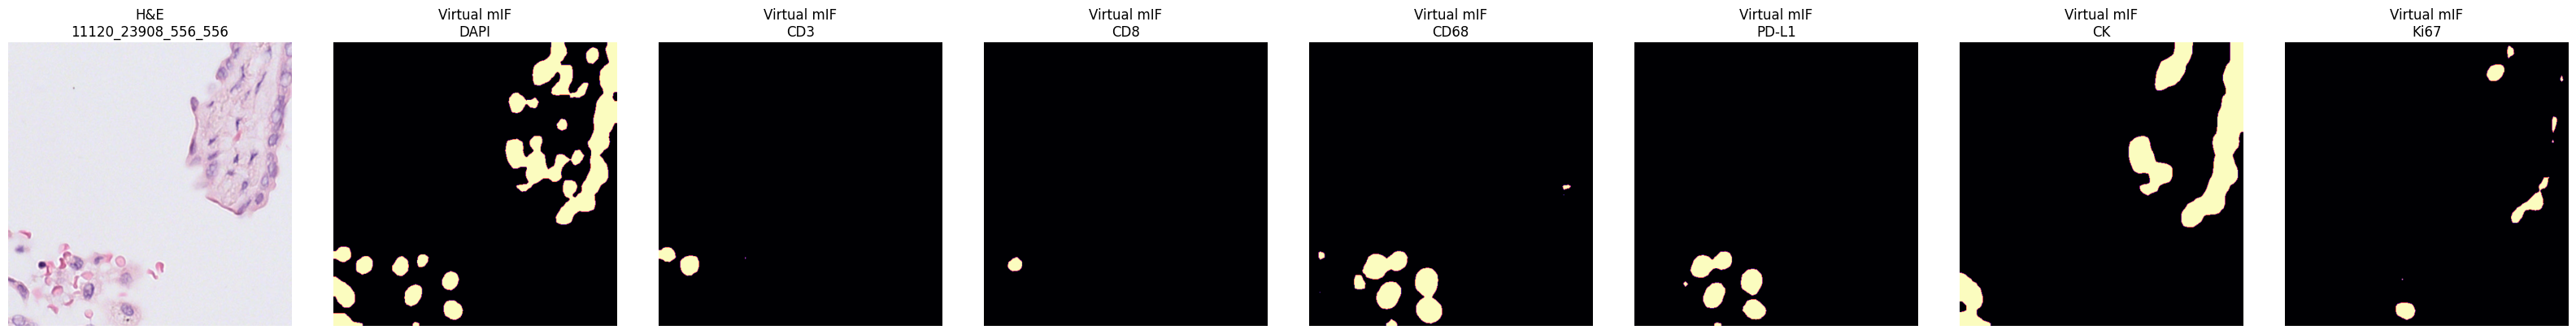

In [7]:
marker_notes = describe_markers(SELECTED_MARKERS)
display(marker_notes)

plot_virtual_mif_for_markers(
    sample=sample,
    markers=SELECTED_MARKERS,
    sample_records=sample_records,
    metadata_df=sample_metadata,
)

## Step 4: Compare detection with the provided data

This section overlays the **cell-aware localized predictions** against the provided reference masks, then summarizes the largest marker-count differences for one sample and across the full set of available samples.

These comparisons use the localized phenotype masks that were created when the unified sample records were built, so the prediction and reference sides are compared with the same nuclei-derived cell definitions.

The goal is to move from visual inspection to a more translational readout: how well the inferred cell-associated marker patterns recover the reference tumor microenvironment composition.

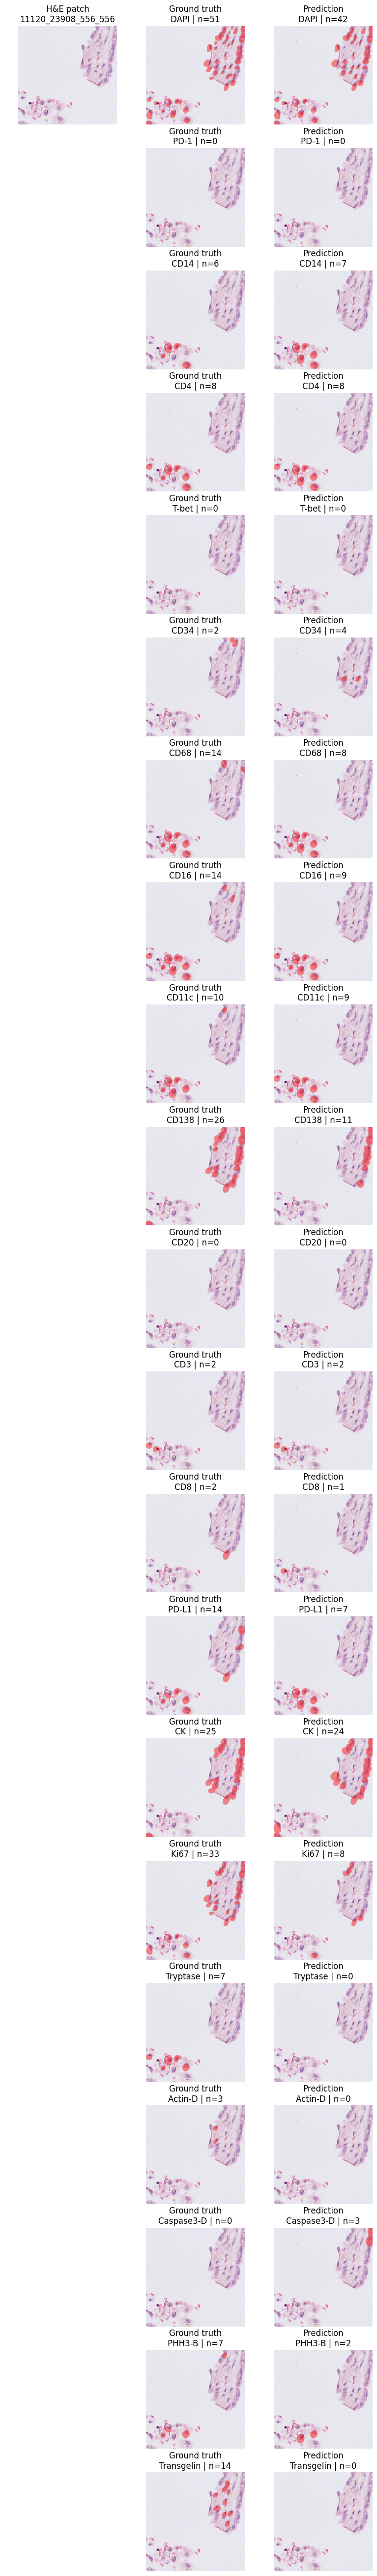

Cell counts for sample '11120_23908_556_556':


,marker,ground_truth_count,prediction_count,count_delta
15,Ki67,33,8,-25
9,CD138,26,11,-15
20,Transgelin,14,0,-14
0,DAPI,51,42,-9
16,Tryptase,7,0,-7
13,PD-L1,14,7,-7
6,CD68,14,8,-6
7,CD16,14,9,-5
19,PHH3-B,7,2,-5
18,Caspase3-D,0,3,3


Total cell counts across all samples:


,marker,ground_truth_count,prediction_count,count_delta
15,Ki67,1329,391,-938
0,DAPI,3198,2409,-789
6,CD68,1254,504,-750
19,PHH3-B,820,129,-691
16,Tryptase,529,32,-497
9,CD138,1116,661,-455
7,CD16,861,476,-385
20,Transgelin,398,30,-368
13,PD-L1,1030,676,-354
5,CD34,690,1003,313


In [8]:
plot_overlay_comparison(
    sample=sample,
    sample_records=sample_records,
    metadata_df=sample_metadata,
    markers=VIRTUAL_PHENOTYPING_MARKERS,
)

comparison_df = get_marker_count_comparison(
    sample=sample,
    sample_records=sample_records,
    metadata_df=sample_metadata,
    channel_names=CHANNEL_NAMES,
).sort_values("count_delta", key=lambda series: series.abs(), ascending=False)

total_counts_df = get_total_marker_count_comparison(
    sample_records=sample_records,
    channel_names=CHANNEL_NAMES,
).sort_values("count_delta", key=lambda series: series.abs(), ascending=False)

top_sample_delta = comparison_df.iloc[0]
top_total_delta = total_counts_df.iloc[0]

print(f"Cell counts for sample '{selected_pair_name}':")
display(comparison_df)
print("Total cell counts across all samples:")
display(total_counts_df)

## Step 5: Visualize tumor microenvironment context on H&E

Localized overlays are often easier to interpret than standalone marker panels because they place predicted cell-associated signals back into tissue architecture. In this epithelial tumor setting, **CK** serves as a practical tumor-lineage surrogate, which makes it useful for visualizing immune exclusion, immune infiltration, compartment boundaries, and proliferative tumor geography.

Before looking at the themed views, it helps to decode the three CK-centered overlays that drive the first figure group. In this notebook, **CK** marks epithelial or tumor-rich regions, so each pair can be read as **tumor geography plus a second biological signal**.

| Overlay pair | Plain-language reading | Pattern to look for |
| --- | --- | --- |
| CK + CD8 | Tumor regions plus cytotoxic T cells | Are CD8 T cells infiltrating tumor nests, sitting mostly at the border, or excluded from the tumor core? |
| CK + CD68 | Tumor regions plus macrophages | Are macrophages mixed into tumor-rich regions or concentrated at the tumor-stroma interface? |
| CK + Ki67 | Tumor regions plus proliferating cells | Do the tumor-rich regions also show strong proliferative activity, suggesting active tumor growth? |

The first theme intentionally combines two immune-interface overlays (`CK + CD8`, `CK + CD68`) with one proliferation overlay (`CK + Ki67`). Read them together as a compact summary of whether tumor-rich regions are being infiltrated, bordered by myeloid cells, and actively cycling.

This section then organizes the overlays into the same five figure themes used below. The table is a **reading guide for the rendered panels**: the overlay-pair column matches the figures, and the interpretation columns tell you what spatial pattern to look for and why it matters biologically.

| Theme shown in figure | Overlay pairs shown | Spatial pattern to look for | Biological interpretation |
| --- | --- | --- | --- |
| Tumor-immune interaction | CK + CD8, CK + CD68, CK + Ki67 | Ask whether CK-rich tumor nests are infiltrated by CD8 T cells, bordered by CD68 macrophages, and co-localized with Ki67-positive proliferative regions. | Reads immune access to tumor, myeloid interface biology, and whether tumor-rich areas are actively proliferating. |
| Immune system structure | CD3 + CD20, CD4 + CD8 | Look for organized lymphoid neighborhoods and whether helper and cytotoxic T-cell populations appear balanced or spatially segregated. | Helps judge whether the immune response looks coordinated, weak, or compositionally skewed. |
| Myeloid and antigen-presenting cells | CD68 + CD11c | Look for where macrophages and dendritic-cell-like populations accumulate: inside tumor-rich tissue, at tumor-stroma interfaces, or in separate niches. | Myeloid-cell distribution can reflect inflammatory tone, antigen presentation, or immune suppression. |
| Immune checkpoint biology | CD8 + PD-L1, CD3 + PD-1 | Look for regions where T cells are present but overlap with checkpoint signaling, which may indicate restrained or exhausted immune activity. | Connects the spatial immune pattern to mechanisms of immune evasion and checkpoint therapy relevance. |
| Stromal and vascular context | CD34 + CK, Tryptase + CD68 | Look for how vessels sit relative to CK-rich tumor regions and whether mast cells and macrophages cluster in stromal or perivascular niches. | Links vascular access, compartment boundaries, and innate immune niches within the supporting tissue context. |

The following figures use the same localized prediction masks used in Step 4, now rendered as multicolor overlays on the H&E patch for qualitative tumor microenvironment interpretation. Because all fields of view come from the same lung-tissue subject, this step is best read as **within-specimen spatial context** rather than between-patient heterogeneity.

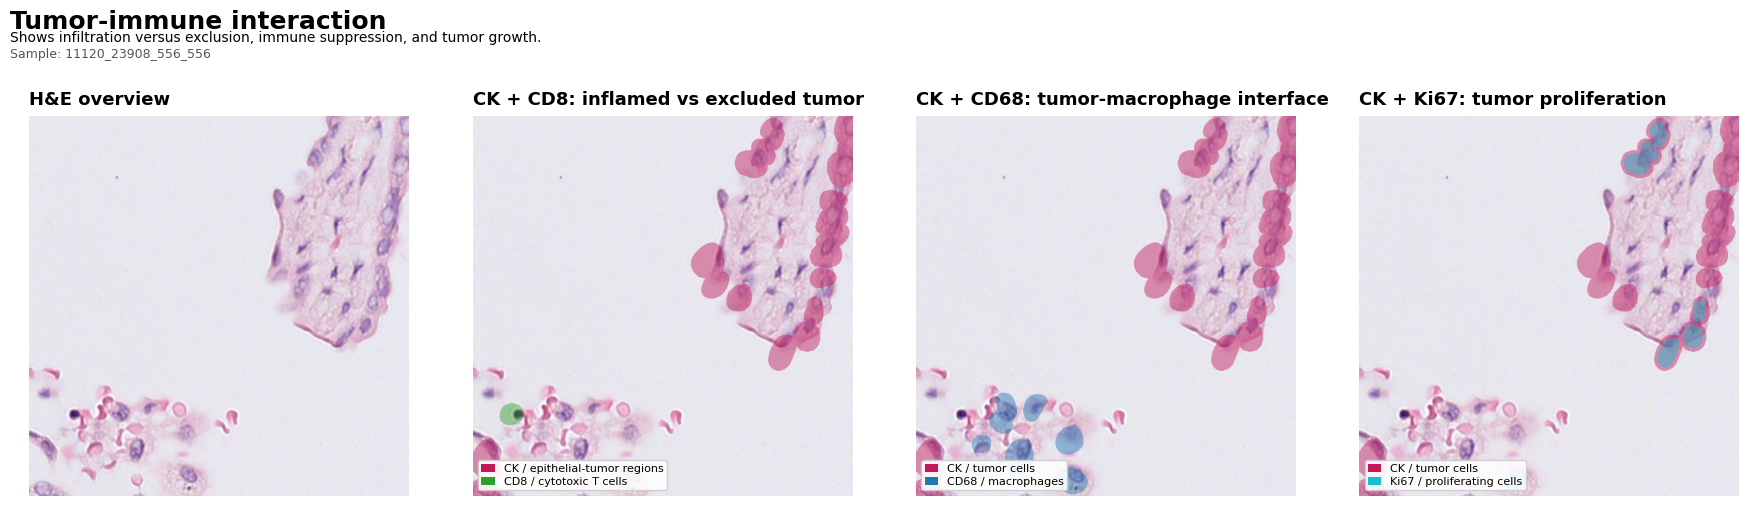

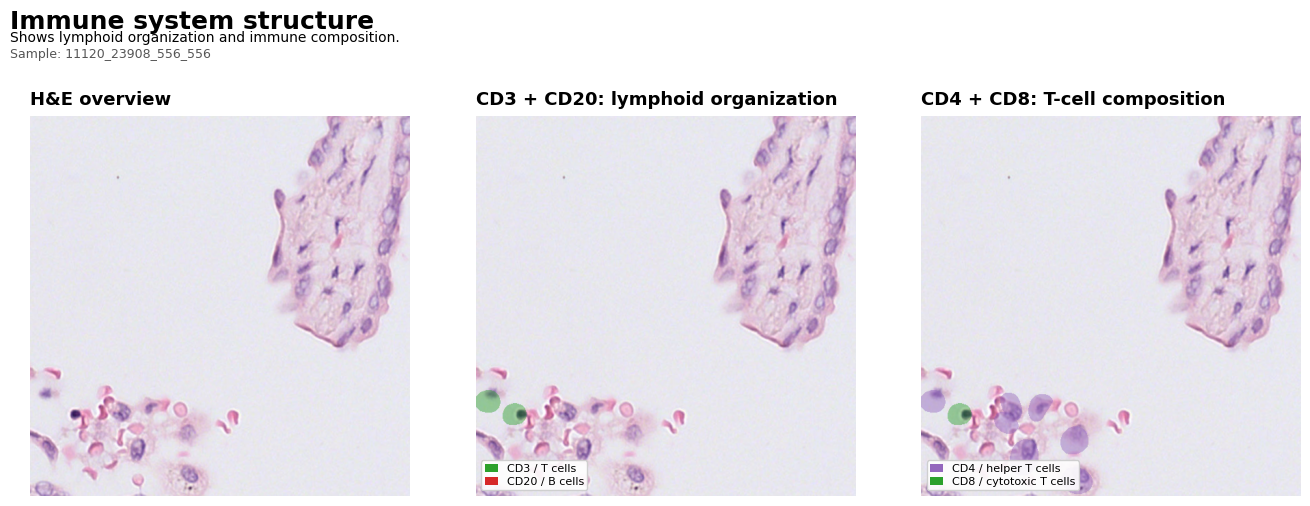

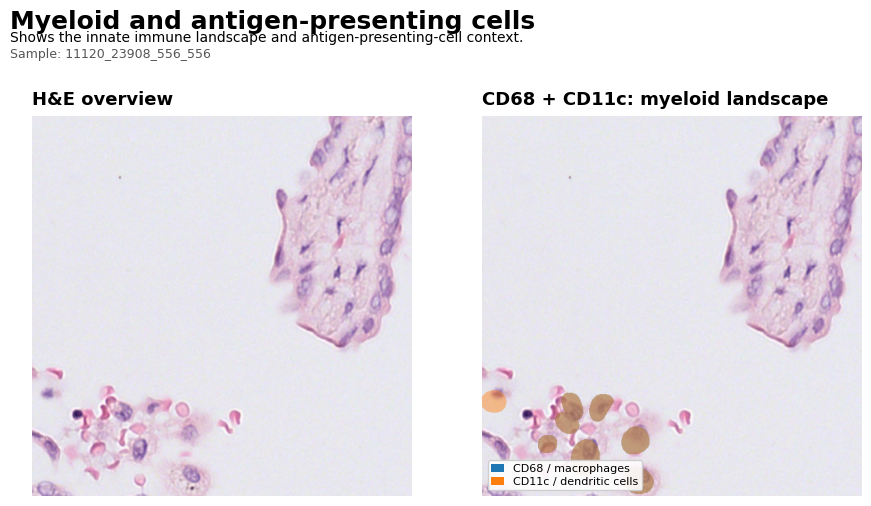

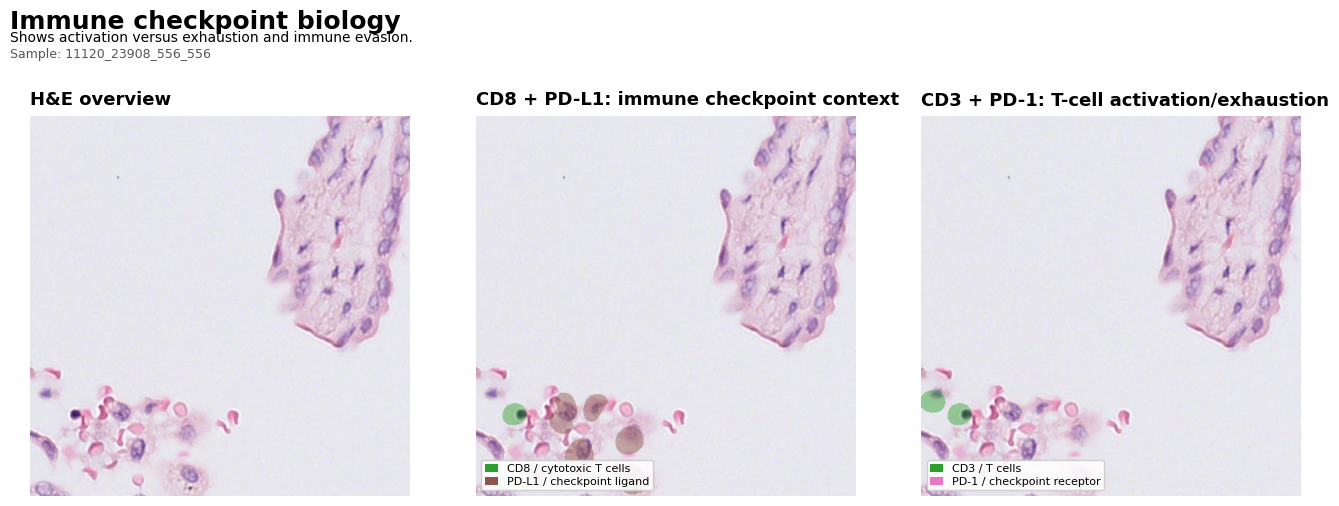

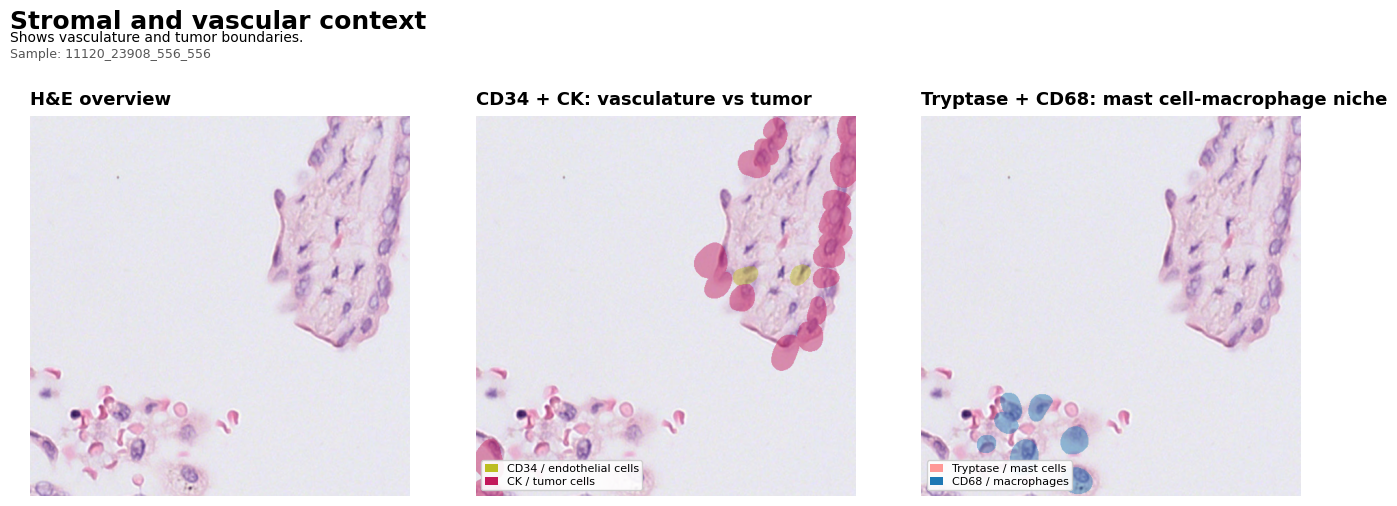

In [9]:
CONTEXT_SAMPLE = sample
# Set CONTEXT_SAMPLE to another sample index if you want to inspect a different patch.
CONTEXT_PAIR_NAME = sample_metadata.iloc[CONTEXT_SAMPLE]["pair_name"]
context_record = sample_records[CONTEXT_PAIR_NAME]
context_localized_mask = context_record["prediction_localized_mask"]
if context_localized_mask is None:
    raise ValueError("Localized prediction masks are required for Step 5 overlays.")

TME_CONTEXT_THEMES = [
    {
        "heading": "Tumor-immune interaction",
        "description": "Shows infiltration versus exclusion, immune suppression, and tumor growth.",
        "layout": "single-row",
        "panels": [
            {
                "title": "CK + CD8: inflamed vs excluded tumor",
                "markers": [
                    ("CK", "#C2185B", "CK / epithelial-tumor regions"),
                    ("CD8", "#2CA02C", "CD8 / cytotoxic T cells"),
                ],
            },
            {
                "title": "CK + CD68: tumor-macrophage interface",
                "markers": [
                    ("CK", "#C2185B", "CK / tumor cells"),
                    ("CD68", "#1F77B4", "CD68 / macrophages"),
                ],
            },
            {
                "title": "CK + Ki67: tumor proliferation",
                "markers": [
                    ("CK", "#C2185B", "CK / tumor cells"),
                    ("Ki67", "#17BECF", "Ki67 / proliferating cells"),
                ],
            },
        ],
    },
    {
        "heading": "Immune system structure",
        "description": "Shows lymphoid organization and immune composition.",
        "panels": [
            {
                "title": "CD3 + CD20: lymphoid organization",
                "markers": [
                    ("CD3", "#2CA02C", "CD3 / T cells"),
                    ("CD20", "#D62728", "CD20 / B cells"),
                ],
            },
            {
                "title": "CD4 + CD8: T-cell composition",
                "markers": [
                    ("CD4", "#9467BD", "CD4 / helper T cells"),
                    ("CD8", "#2CA02C", "CD8 / cytotoxic T cells"),
                ],
            },
        ],
    },
    {
        "heading": "Myeloid and antigen-presenting cells",
        "description": "Shows the innate immune landscape and antigen-presenting-cell context.",
        "panels": [
            {
                "title": "CD68 + CD11c: myeloid landscape",
                "markers": [
                    ("CD68", "#1F77B4", "CD68 / macrophages"),
                    ("CD11c", "#FF7F0E", "CD11c / dendritic cells"),
                ],
            },
        ],
    },
    {
        "heading": "Immune checkpoint biology",
        "description": "Shows activation versus exhaustion and immune evasion.",
        "panels": [
            {
                "title": "CD8 + PD-L1: immune checkpoint context",
                "markers": [
                    ("CD8", "#2CA02C", "CD8 / cytotoxic T cells"),
                    ("PD-L1", "#8C564B", "PD-L1 / checkpoint ligand"),
                ],
            },
            {
                "title": "CD3 + PD-1: T-cell activation/exhaustion",
                "markers": [
                    ("CD3", "#2CA02C", "CD3 / T cells"),
                    ("PD-1", "#E377C2", "PD-1 / checkpoint receptor"),
                ],
            },
        ],
    },
    {
        "heading": "Stromal and vascular context",
        "description": "Shows vasculature and tumor boundaries.",
        "panels": [
            {
                "title": "CD34 + CK: vasculature vs tumor",
                "markers": [
                    ("CD34", "#BCBD22", "CD34 / endothelial cells"),
                    ("CK", "#C2185B", "CK / tumor cells"),
                ],
            },
            {
                "title": "Tryptase + CD68: mast cell-macrophage niche",
                "markers": [
                    ("Tryptase", "#FF9896", "Tryptase / mast cells"),
                    ("CD68", "#1F77B4", "CD68 / macrophages"),
                ],
            },
        ],
    },
]

context_bbox = get_tissue_bbox(context_record["he_image"])
for theme in TME_CONTEXT_THEMES:
    render_context_theme(
        theme=theme,
        context_record=context_record,
        localized_mask=context_localized_mask,
        bbox=context_bbox,
        pair_name=CONTEXT_PAIR_NAME,
    )

## Conclusions

This notebook demonstrates how to run GigaTIME on H&E images and convert virtual marker predictions into biologically meaningful insights about the tumor microenvironment. By localizing predicted markers at the cell level and comparing them with reference mIF labels, the workflow enables both quantitative evaluation and intuitive spatial interpretation on tissue.

Key takeaways:

Virtual phenotyping reveals interpretable tumor microenvironment structure directly from H&E.
Cell-aware localization improves biological relevance in prediction vs. reference comparisons.
The workflow supports both model inference and downstream interpretation.
Observed variation is driven by spatial heterogeneity within a single specimen.

These results are illustrative rather than definitive, as they are based on a small, single-subject dataset. In practice, broader validation and dataset-specific fine-tuning are required for translational or clinical use.